In [1]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.windows import Window
from rasterio.mask import mask

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps
)

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4
BATCH_SIZE = 1024
NUM_WORKERS = 4     
PIN_MEMORY = False

In [2]:
repo_root = os.getcwd()
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Train Data

In [3]:
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_no_manila_path, "by_box", "greater_mm_bbox_dem_cop_noManila_box.tif")
train_dem_data, train_dem_meta = load_dem(dem_path)
dem_stats = get_raster_stats(train_dem_data, "DEM")
print_raster_stats(dem_stats)

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_no_manila_path, "by_box", "GM_Infilt_noManila_box.tif")
train_infilt_data, train_infilt_meta = load_infiltration_map(infilt_path)
infilt_stats = get_raster_stats(train_infilt_data, "Infiltration Map")
print_raster_stats(infilt_stats)

print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(gmm_no_manila_path, "by_box", "GM_LU_noManila_box.tif")
train_landuse_data, landuse_meta = load_landuse_map(landuse_path)
landuse_stats = get_raster_stats(train_landuse_data, "Landuse Map")
print_raster_stats(landuse_stats)

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_no_manila_path, "by_box")
flood_maps_train, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)
print(f"\nFlood maps successfully loaded: {len(flood_maps_train)}")
if len(flood_maps_train) >= NUM_SCENARIO:
    flood_stats = get_raster_stats(flood_maps_train[-1], "Flood Map RS50")


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -4.9004
Max value:     466.3908
Mean value:    44.9711
Std dev:       71.0011
Valid pixels:  1,273,959 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.5198
Std dev:       0.9750
Valid pixels:  1,273,959 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.8709
Std dev:       2.5478
Valid pixels:  1,273,959 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

# Test Data

In [4]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "exp-des-4", "manila_bbox_dem_cop.tif")
dem_data_test, dem_meta = load_dem(dem_path)
dem_stats = get_raster_stats(dem_data_test, "DEM")
print_raster_stats(dem_stats)

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "exp-des-4", "GM_Infilt_Manila_box.tif")
infilt_data_test, infilt_meta = load_infiltration_map(infilt_path)
infilt_stats = get_raster_stats(infilt_data_test, "Infiltration Map")
print_raster_stats(infilt_stats)

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(manila_path, "exp-des-4", "GM_LU_Manila_box.tif")
landuse_data_test, landuse_meta = load_landuse_map(landuse_path)
landuse_stats = get_raster_stats(landuse_data_test, "Landuse Map")
print_raster_stats(landuse_stats) 

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "exp-des-4")
flood_maps_test, flood_metadata = manila_path_shape_load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)
flood_stats = get_raster_stats(flood_maps_test[-1], "Flood Map RS50")
print_raster_stats(flood_stats)


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1999
Std dev:       5.6200
Valid pixels:  103,041 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0126
Std dev:       0.1790
Valid pixels:  103,041 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7113
Std dev:       1.6436
Valid pixels:  103,041 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 1125), dtyp

# Manila Mask

In [5]:
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
mask_data, mask_meta = load_manila_mask(mask_path)
mask_stats = get_raster_stats(mask_data, "Mask")
print_raster_stats(mask_stats)


--- Loading Manila Mask ---
Manila mask loaded: shape (389, 358), dtype float32

Statistics for: Mask
Shape:         (389, 358)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0747
Std dev:       0.2629
Valid pixels:  139,262 / 139,262



In [6]:
from scipy.ndimage import zoom

# Current mask shape vs required shape
print(f"\nCurrent mask shape: {mask_data.shape}")
# Resize mask to match raster dimensions
target_shape = (1224, 1125)
zoom_factors = (target_shape[0] / mask_data.shape[0], 
                target_shape[1] / mask_data.shape[1])
print(f"\nZoom factors: {zoom_factors}")
mask_resized = zoom(mask_data, zoom_factors, order=0)  # order=0 = nearest neighbor
print(f"Resized mask shape: {mask_resized.shape}")

# Verify values remain binary
unique_values = np.unique(mask_resized)
print(f"Unique values in resized mask: {unique_values}")

# Statistics
mask_resized_stats = get_raster_stats(mask_resized, "Manila Mask (Resized)")
print_raster_stats(mask_resized_stats)
manila_box_mask = mask_resized


Current mask shape: (389, 358)

Zoom factors: (3.146529562982005, 3.142458100558659)
Resized mask shape: (1224, 1125)
Unique values in resized mask: [0. 1.]



Statistics for: Manila Mask (Resized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0751
Std dev:       0.2635
Valid pixels:  1,377,000 / 1,377,000



In [7]:
print(f"  - train_dem_data (train): {train_dem_data.shape}")
print(f"  - train_infilt_data (train): {train_infilt_data.shape}")
print(f"  - train_landuse_data (train): {train_landuse_data.shape}")
print(f"  - dem_data_test (test): {dem_data_test.shape}")
print(f"  - infilt_data_test (test): {infilt_data_test.shape}")
print(f"  - landuse_data_test (test): {landuse_data_test.shape}")
print(f"  - flood_maps_train (train): {len(flood_maps_train)} maps")
print(f"  - flood_maps_test (test): {len(flood_maps_test)} maps")

  - train_dem_data (train): (1224, 1125)
  - train_infilt_data (train): (1224, 1125)
  - train_landuse_data (train): (1224, 1125)
  - dem_data_test (test): (1224, 1125)
  - infilt_data_test (test): (1224, 1125)
  - landuse_data_test (test): (1224, 1125)
  - flood_maps_train (train): 50 maps
  - flood_maps_test (test): 50 maps


In [8]:
from data_preprocessing import preprocess_spatial_data
import matplotlib.pyplot as plt

preprocessed = preprocess_spatial_data(
    train_dem=train_dem_data,
    train_infilt=train_infilt_data,
    train_landuse=train_landuse_data,
    test_dem=dem_data_test,
    test_infilt=infilt_data_test,
    test_landuse=landuse_data_test,
    mask=manila_box_mask,
    target_shape=(1152, 1152),      
    nodata_method='interpolate', 
    norm_method='minmax'  
)


PHASE 2: SPATIAL INPUT PREPROCESSING

[2.1] Handling NoData Values
----------------------------------------------------------------------
  DEM (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  DEM (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Infiltration (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Infiltration (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Landuse (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Landuse (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor

✓ NoData handling complete

[2.2] Resizing to (1152, 1152)
----------------------------------------------------------------------
  Current: (1224, 1125)
  Target: (1152, 1152)
  Train DEM: (1224, 1125) → (1152, 1152) (bilinear)
  Train Infiltration: (1224, 1125) → (1152, 1152) (bilinear)
  Train Landuse: (1224, 1125) → (1152, 1152) (nearest)
  T

In [9]:
# Extract preprocessed data
train_dem_preprocessed = preprocessed['train']['dem']
train_infilt_preprocessed = preprocessed['train']['infiltration']
train_landuse_preprocessed = preprocessed['train']['landuse']
test_dem_preprocessed = preprocessed['test']['dem']
test_infilt_preprocessed = preprocessed['test']['infiltration']
test_landuse_preprocessed = preprocessed['test']['landuse']
mask_preprocessed = preprocessed['mask']

print(f"  - train_dem_preprocessed: {train_dem_preprocessed.shape}")
print(f"  - train_infilt_preprocessed: {train_infilt_preprocessed.shape}")
print(f"  - train_landuse_preprocessed: {train_landuse_preprocessed.shape}")
print(f"  - test_dem_preprocessed: {test_dem_preprocessed.shape}")
print(f"  - test_infilt_preprocessed: {test_infilt_preprocessed.shape}")
print(f"  - test_landuse_preprocessed: {test_landuse_preprocessed.shape}")
print(f"  - mask_preprocessed: {mask_preprocessed.shape}")
print(f"  - flood_maps_train: {len(flood_maps_train)} scenarios")
print(f"  - flood_maps_test: {len(flood_maps_test)} scenarios")

  - train_dem_preprocessed: (1152, 1152)
  - train_infilt_preprocessed: (1152, 1152)
  - train_landuse_preprocessed: (1152, 1152)
  - test_dem_preprocessed: (1152, 1152)
  - test_infilt_preprocessed: (1152, 1152)
  - test_landuse_preprocessed: (1152, 1152)
  - mask_preprocessed: (1152, 1152)
  - flood_maps_train: 50 scenarios
  - flood_maps_test: 50 scenarios


# Rainfall

In [10]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")

LOADING RAINFALL SCENARIOS

Rainfall scenarios successfully loaded: 50


In [11]:
from rainfall import preprocess_rainfall_sequences, visualize_rainfall_sequences, visualize_conditioning_vectors

# Preprocess rainfall sequences
rainfall_results = preprocess_rainfall_sequences(rainfall_scenarios=rainfall_scenarios, norm_method='global_max', info_csv_path='./info.csv')

# Output now includes:
rainfall_results['conditioning_vectors']  
rainfall_results['encoding_info'] 


PHASE 3: RAINFALL TEMPORAL SEQUENCE PREPROCESSING

[3.1] Extracting Rainfall Sequences
----------------------------------------------------------------------
  RS01: 13 timesteps, peak=92.49 mm/hr at t=2
  RS02: 13 timesteps, peak=14.60 mm/hr at t=2
  RS03: 13 timesteps, peak=82.76 mm/hr at t=2
  RS04: 13 timesteps, peak=131.44 mm/hr at t=2
  RS05: 13 timesteps, peak=41.38 mm/hr at t=2
  RS06: 13 timesteps, peak=80.32 mm/hr at t=2
  RS07: 13 timesteps, peak=26.77 mm/hr at t=2
  RS08: 13 timesteps, peak=51.11 mm/hr at t=2
  RS09: 13 timesteps, peak=189.85 mm/hr at t=2
  RS10: 13 timesteps, peak=99.79 mm/hr at t=2
  RS11: 13 timesteps, peak=58.74 mm/hr at t=5
  RS20: 13 timesteps, peak=78.89 mm/hr at t=5
  RS21: 13 timesteps, peak=34.08 mm/hr at t=9
  RS30: 13 timesteps, peak=51.11 mm/hr at t=9
  RS31: 13 timesteps, peak=14.77 mm/hr at t=4
  RS50: 13 timesteps, peak=27.69 mm/hr at t=1

✓ Extracted 50 sequences
  Shape: (50, 13)
  ✓ All sequences have 13 timesteps

[3.2] Normalizing Sequ

{'pattern_encoding': {0: 'SCS‑style front-loaded (convective – similar to NRCS Type II)',
  1: 'SCS-style balanced (intermediate)',
  2: 'SCS-style back-loaded (frontal – similar to Type I)',
  3: 'Triangular / Chicago-style with peak at fraction of duration'},
 'max_depth_mm': 78.0,
 'conditioning_dims': 4,
 'dim_names': ['pattern_type', 'depth_normalized', 'tpeak', 'has_tpeak'],
 'pattern_names': ['Front-loaded', 'Balanced', 'Back-loaded', 'Triangular']}

# Ground Truth (Flood Maps)

In [12]:
from flood_maps import categorize_flood_maps, resize_flood_maps, visualize_categorized_maps  

# Create masks (train = GMM outskirts, test = Manila core)
train_mask = 1 - mask_preprocessed  # Inverse of Manila box
test_mask = mask_preprocessed       # Manila box

flood_maps_train_resized = resize_flood_maps(flood_maps=flood_maps_train, target_shape=(1152, 1152), split_name='Train')
flood_maps_test_resized = resize_flood_maps(flood_maps=flood_maps_test, target_shape=(1152, 1152), split_name='Test')


Resizing Train Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Progress: 30/50 maps resized
    Progress: 35/50 maps resized
    Progress: 40/50 maps resized
    Progress: 45/50 maps resized
    Progress: 50/50 maps resized
  ✓ All flood maps resized to (1152, 1152)

Resizing Test Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Pro

In [13]:
# Categorize flood maps
categorization_results = categorize_flood_maps(
    train_flood_maps=flood_maps_train_resized,      
    test_flood_maps=flood_maps_test_resized,        
    train_mask=train_mask,
    test_mask=test_mask,
    patch_size=PATCH_SIZE,                          
    categorization_method='majority_vote',   
    class_thresholds=[0.15, 0.24, 0.46, 0.68]
)


PHASE 4: FLOOD MAP CATEGORIZATION

[4.1] Flood Susceptibility Classes
----------------------------------------------------------------------
  Class 0 - No Flood    : [0.00, 0.15) meters
  Class 1 - Light       : [0.15, 0.24) meters
  Class 2 - Moderate    : [0.24, 0.46) meters
  Class 3 - Heavy       : [0.46, 0.68) meters
  Class 4 - Extreme     : [0.68, ∞) meters

[4.2] Patch Configuration
----------------------------------------------------------------------
  Spatial shape: (1152, 1152)
  Patch size: 4×4
  Patches per dimension: 288×288
  Total patches: 82,944
  Categorization method: majority_vote

[4.3] Categorizing Flood Maps
----------------------------------------------------------------------

  Train Set (50 scenarios):
    RS01: 76,553 valid patches, 6,391 NoData
    RS02: 76,553 valid patches, 6,391 NoData
    RS03: 76,553 valid patches, 6,391 NoData
    RS04: 76,553 valid patches, 6,391 NoData
    RS05: 76,553 valid patches, 6,391 NoData
    RS06: 76,553 valid patches, 6

# Rainfall-based Partitioning

In [14]:
from data_splitting import split_spatial_data

split_results = split_spatial_data( 
    categorization_results=categorization_results,
    preprocessed_spatial=preprocessed, rainfall_results=rainfall_results,
    train_ratio=0.70, random_seed=42, patch_size=PATCH_SIZE
)

X_train_spatial = split_results['train']['spatial_patches']      
X_train_rainfall = split_results['train']['rainfall_sequences']  
y_train = split_results['train']['labels']                      

X_test_spatial = split_results['test']['spatial_patches']        
X_test_rainfall = split_results['test']['rainfall_sequences']     
y_test = split_results['test']['labels']   


SPATIAL DATA SPLITTING (WITH CONDITIONING)

[5.1] Spatial Split Logic
----------------------------------------------------------------------
  Data Structure:
    • Train region: Greater Metro Manila (GMM) - outside Manila box
    • Test region: Metro Manila core - inside Manila box
    • Spatially complementary (non-overlapping)

  Split Strategy:
    • All 50 scenarios used for BOTH regions
    • Training scenarios → GMM patches
    • Testing scenarios → Manila patches
    • Conditioning vectors replicated per patch (NEW)

[5.2] Spatial Masks
----------------------------------------------------------------------
  Total pixels: 1,327,104
  GMM region (train): 1,227,417 pixels (92.5%)
  Manila region (test): 99,687 pixels (7.5%)
  Coverage check: 1,327,104 / 1,327,104 ✓

  Patch Alignment:
    Train (GMM): 76,553 patches
    Test (Manila): 6,075 patches

[5.3] Random Scenario Assignment
----------------------------------------------------------------------
  Total scenarios: 50
  Tra

In [15]:
print(f"\nFinal Dataset Shapes:")
print("X_train_spatial: ", X_train_spatial.shape)
print("X_train_rainfall: ", X_train_rainfall.shape)
print("y_train: ", y_train.shape)
print("X_test_spatial: ", X_test_spatial.shape)
print("X_test_rainfall: ", X_test_rainfall.shape)
print("y_test: ", y_test.shape)


Final Dataset Shapes:
X_train_spatial:  (2679355, 3, 4, 4)
X_train_rainfall:  (2679355, 13)
y_train:  (2679355,)
X_test_spatial:  (91125, 3, 4, 4)
X_test_rainfall:  (91125, 13)
y_test:  (91125,)


# Dataset

In [ ]:
from rf_config import RFConfig
from rf_dataset import load_or_build_rf_datasets

from feature_engineering import (  
    N_FEATURES,
    get_feature_names,
    compute_slope_map,
    build_feature_matrix,
    validate_feature_matrix,
)

cfg = RFConfig()
cfg.summary()

rf_data = build_rf_datasets(
    split_results        = split_results,
    rainfall_results     = rainfall_results,
    preprocessed_spatial = preprocessed,
    cfg                  = cfg,
    cache_dir            = cfg.output_dir / 'cache',  # skip recompute on re-run
)

X_train       = rf_data['X_train']        # (N_tr, 35)
X_test        = rf_data['X_test']         # (N_te, 35)
y_train       = rf_data['y_train']        # (N_tr,)
y_test        = rf_data['y_test']         # (N_te,)
feature_names = rf_data['feature_names']  # list[str] len=35
train_meta    = rf_data['train_meta']     # list of {scenario_id, patch_coord}
test_meta     = rf_data['test_meta']


RFConfig
  Features       : 35 total per patch
    DEM          : mean, std, min, max, slope_mean, slope_std, entropy  (7)
    Infiltration : mean, std, min, max, entropy                         (5)
    Land use     : mode, n_unique, entropy                              (3)
    Rainfall     : 13 timesteps + total / peak / tpeak_idx             (16)
    Conditioning : pattern_type, depth_norm, tpeak, has_tpeak           (4)
  Trees          : 500
  Max depth      : 20
  Max features   : sqrt  (per split)
  Bootstrap      : True  sample_frac=0.8
  OOB score      : True
  Min split      : 10  min_leaf=5
  CCP alpha      : 0.0
  Class weights  : yes  power=0.5
  CV strategy    : 2-fold on patch indices  (val F1 optimistic)
  n_jobs         : -1
  Output dir     : outputs_rf

RF DATASET BUILDER

  Computing slope map from full training DEM...
[compute_slope_map]  slope range: [0.000000, 0.103493]  mean=0.003912

  --- TRAIN SPLIT ---
    spatial      : (2679355, 3, 4, 4)
    rainfall     :

  Features: 100%|██████████| 11/11 [04:07<00:00, 22.49s/it]


  ✓ Done  shape=(2679355, 35)  dtype=float32

  Feature                     Mean       Std       Min       Max
  ──────────────────────  ────────  ────────  ────────  ────────
  dem_mean                  0.1098    0.1499    0.0124    0.9863
  dem_std                   0.0045    0.0071    0.0000    0.0789
  dem_min                   0.1023    0.1418    0.0072    0.9695
  dem_max                   0.1178    0.1583    0.0124    1.0000
  dem_slope_mean            0.0010    0.0010    0.0000    0.0097
  dem_slope_std             0.0006    0.0005    0.0000    0.0045
  dem_entropy               2.3492    1.3898    0.0000    3.8750
  infilt_mean               0.1414    0.2555    0.0000    0.9953
  infilt_std                0.0159    0.0571    0.0000    0.4593
  infilt_min                0.1212    0.2460    0.0000    0.9508
  infilt_max                0.1632    0.2779    0.0000    1.0000
  infilt_entropy            0.2755    0.5883    0.0000    3.0778
  landuse_mode              0.2767    0.4474

  Features: 100%|██████████| 1/1 [00:05<00:00,  5.32s/it]


  ✓ Done  shape=(91125, 35)  dtype=float32

  Feature                     Mean       Std       Min       Max
  ──────────────────────  ────────  ────────  ────────  ────────
  dem_mean                  0.0274    0.0109    0.0145    0.0933
  dem_std                   0.0024    0.0022    0.0000    0.0215
  dem_min                   0.0237    0.0089    0.0000    0.0846
  dem_max                   0.0318    0.0137    0.0145    0.1102
  dem_slope_mean            0.0005    0.0006    0.0000    0.0030
  dem_slope_std             0.0004    0.0004    0.0000    0.0018
  dem_entropy               2.3313    1.3781    0.0000    3.7500
  infilt_mean               0.0035    0.0433    0.0000    0.7514
  infilt_std                0.0016    0.0194    0.0000    0.3528
  infilt_min                0.0016    0.0315    0.0000    0.7514
  infilt_max                0.0059    0.0625    0.0000    0.7514
  infilt_entropy            0.0102    0.1210    0.0000    2.3496
  landuse_mode              0.2821    0.4500  

# Training


Random Forest 2-Fold Training  (patch-level split, mirrors XGB/ViT)
  Total patches : 2,679,355
  Features      : 35
  Trees         : 500

────────────────────────────────────────────────────────────
FOLD 1 / 2
  Train patches : 1,339,677
  Val   patches : 1,339,678
────────────────────────────────────────────────────────────

Sample weights  (power=0.5):
  Class 0 (No Flood  ):    974,714  ( 72.8%)  ->  raw=1.1724
  Class 1 (Light     ):     35,042  (  2.6%)  ->  raw=6.1831
  Class 2 (Moderate  ):     65,661  (  4.9%)  ->  raw=4.5170
  Class 3 (Heavy     ):     37,380  (  2.8%)  ->  raw=5.9866
  Class 4 (Extreme   ):    226,880  ( 16.9%)  ->  raw=2.4300
  Normalised : [0.2889, 1.5238, 1.1132, 1.4753, 0.5988]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  4.0min finished



  OOB accuracy  : 0.8304  (in-bag estimate)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    9.4s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:   11.1s finished



Fold 1 Validation Metrics
  Accuracy     : 0.8308
  Macro F1     : 0.5032
  Weighted F1  : 0.8252
  Critical Recall (Heavy+Extreme): 0.6982
  OOB Score    : 0.8304

  Class            Prec      Rec       F1
  ──────────────────────────────────────
  No Flood       0.8970   0.9369   0.9165
  Light          0.2103   0.3050   0.2490
  Moderate       0.3940   0.2755   0.3243
  Heavy          0.3612   0.2108   0.2663
  Extreme        0.8051   0.7193   0.7598

  Top-5 features (MDI importance):
    1. dem_mean                0.1301
    2. dem_std                 0.1052
    3. dem_max                 0.1037
    4. dem_entropy             0.1019
    5. dem_min                 0.0899
  Checkpoint -> outputs_rf\checkpoints\fold_1_best.pkl

  Fold 1 complete  (323.9s)  val macro_f1=0.5032

────────────────────────────────────────────────────────────
FOLD 2 / 2
  Train patches : 1,339,678
  Val   patches : 1,339,677
────────────────────────────────────────────────────────────

Sample weights  (po

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.6min finished



  OOB accuracy  : 0.8303  (in-bag estimate)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    9.7s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:   11.4s finished



Fold 2 Validation Metrics
  Accuracy     : 0.8300
  Macro F1     : 0.5021
  Weighted F1  : 0.8246
  Critical Recall (Heavy+Extreme): 0.6953
  OOB Score    : 0.8303

  Class            Prec      Rec       F1
  ──────────────────────────────────────
  No Flood       0.8977   0.9352   0.9160
  Light          0.2013   0.3123   0.2448
  Moderate       0.3972   0.2764   0.3260
  Heavy          0.3982   0.1998   0.2660
  Extreme        0.7974   0.7219   0.7578

  Top-5 features (MDI importance):
    1. dem_mean                0.1253
    2. dem_entropy             0.1035
    3. dem_std                 0.1029
    4. dem_max                 0.1022
    5. dem_min                 0.0946
  Checkpoint -> outputs_rf\checkpoints\fold_2_best.pkl

  Fold 2 complete  (300.3s)  val macro_f1=0.5021

K-FOLD COMPLETE  |  Best fold: 1  |  Best val macro_f1: 0.5032
  Fold log -> outputs_rf\logs\fold_results.json
  Fold plot -> outputs_rf\logs\fold_summary.png


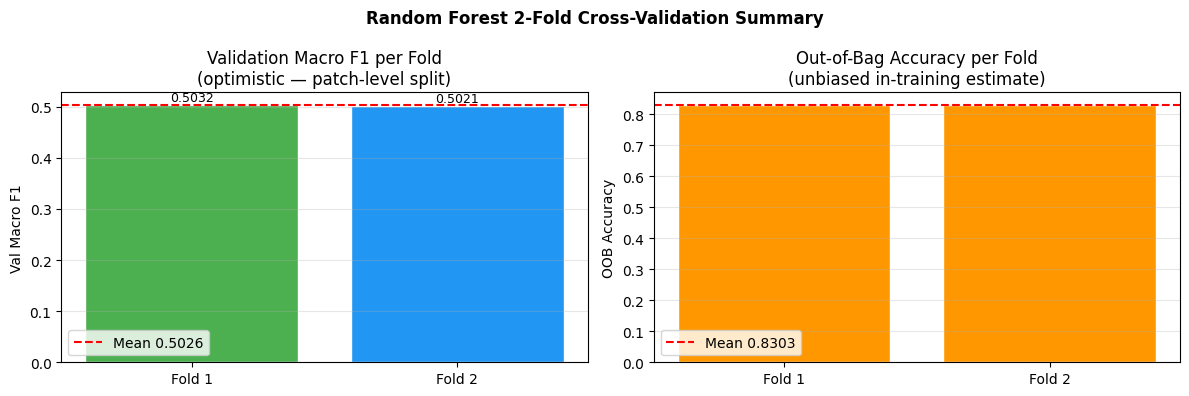

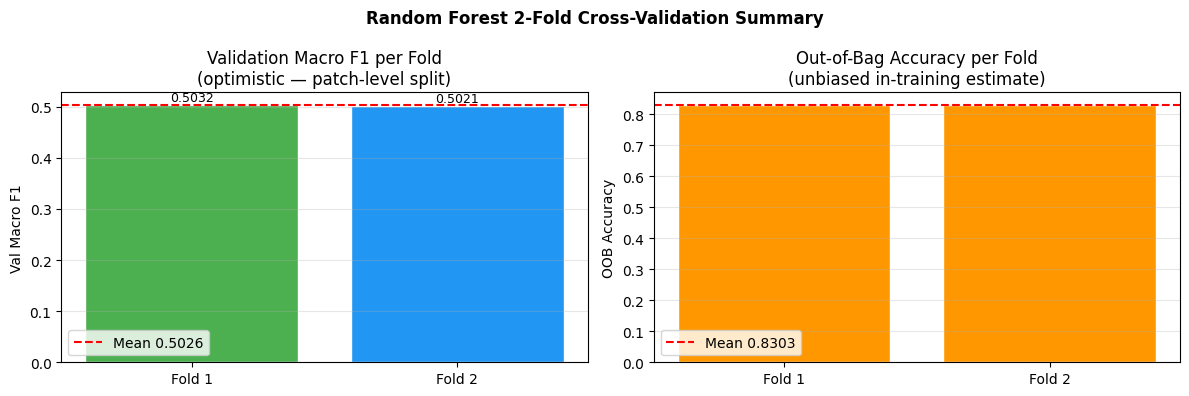

In [19]:
from rf_training import train_kfold_rf, plot_fold_summary_rf

fold_results, best_fold_idx = train_kfold_rf(
    X_train       = X_train,
    y_train       = y_train,
    cfg           = cfg,
    feature_names = feature_names,
)

best_model = fold_results[best_fold_idx]['model']
plot_fold_summary_rf(fold_results, cfg)

# Test Evaluation


Running Test evaluation on 91,125 patches...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.6s finished



Test Metrics
  Accuracy     : 0.8013
  Macro F1     : 0.3989
  Weighted F1  : 0.7803
  Critical Recall (Heavy+Extreme): 0.5757

  Class            Prec      Rec       F1
  ──────────────────────────────────────
  No Flood       0.8687   0.9569   0.9107
  Light          0.1183   0.2631   0.1632
  Moderate       0.3396   0.0645   0.1085
  Heavy          0.2535   0.0432   0.0738
  Extreme        0.8460   0.6548   0.7382

  Confidence — mean=0.7053  median=0.7867  std=0.2269  range=[0.2143, 0.9941]
  Low(<0.5)=22.5%  Mid=30.1%  High(>0.8)=47.4%
  Results -> outputs_rf\logs/test_results.json
  Feature importance plot -> outputs_rf\logs\feature_importance_mdi.png


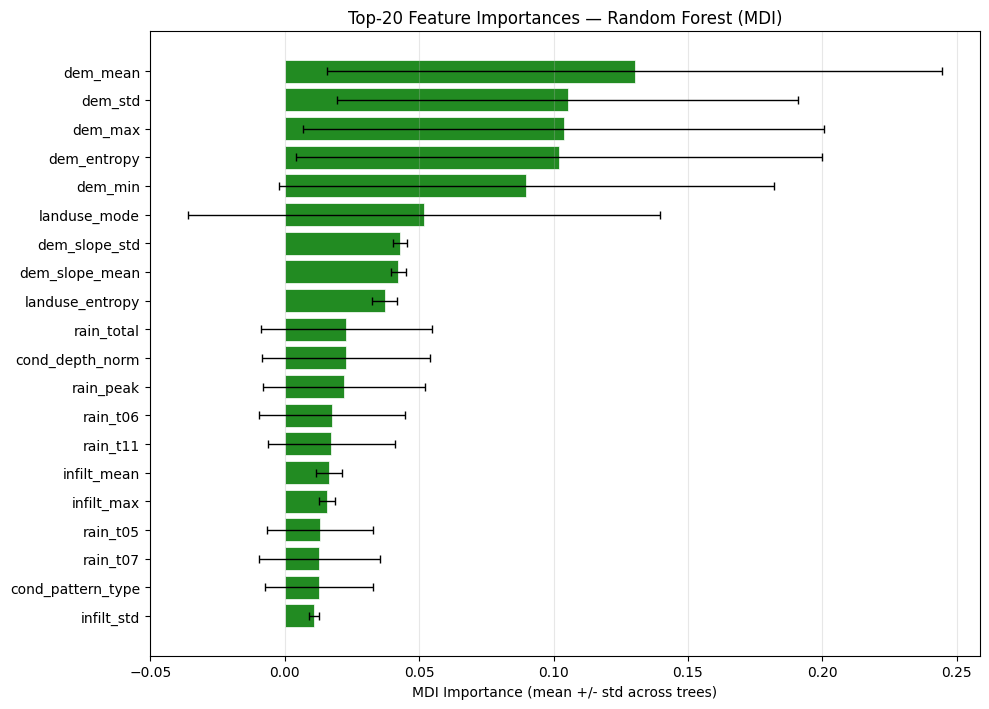

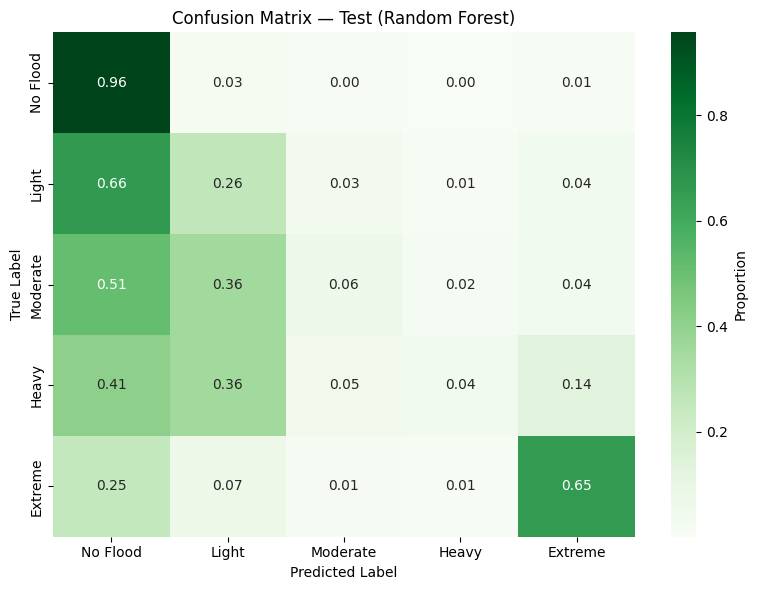

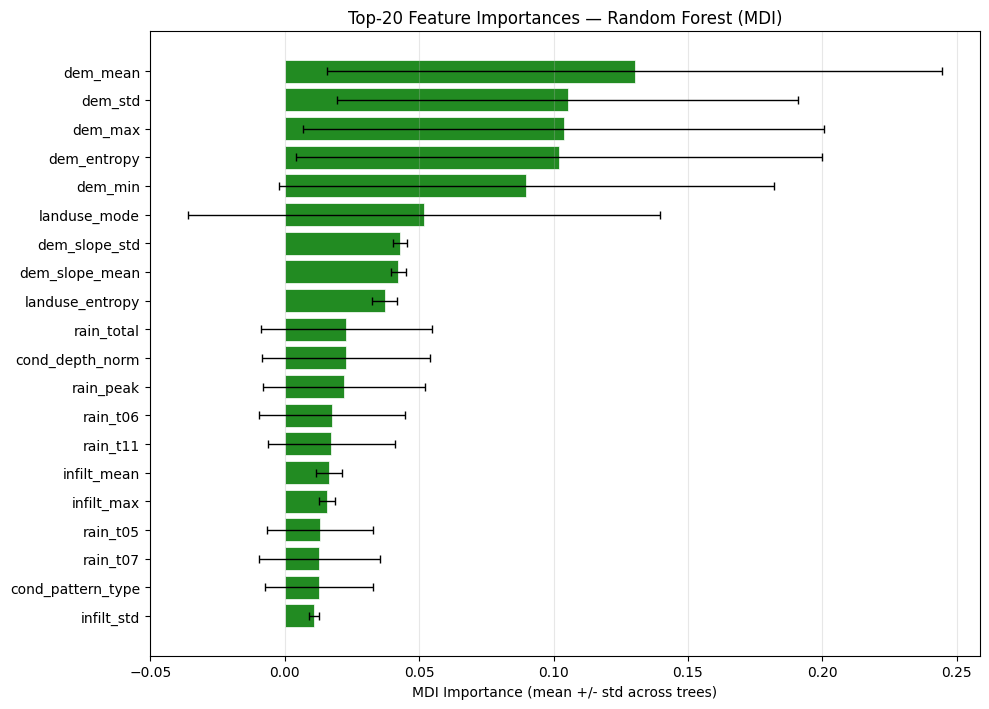

In [20]:
from rf_training import evaluate_rf, plot_feature_importance

test_metrics = evaluate_rf(best_model, X_test, y_test, cfg)
plot_feature_importance(best_model, feature_names, cfg, top_n=20)

# Prediction


[Reconstructing Ground Truth Maps — Random Forest]
  Scenario 3: 97,200 valid pixels
  Scenario 8: 97,200 valid pixels
  Scenario 11: 97,200 valid pixels
  Scenario 15: 97,200 valid pixels
  Scenario 19: 97,200 valid pixels
  Scenario 21: 97,200 valid pixels
  Scenario 23: 97,200 valid pixels
  Scenario 24: 97,200 valid pixels
  Scenario 29: 97,200 valid pixels
  Scenario 36: 97,200 valid pixels
  Scenario 39: 97,200 valid pixels
  Scenario 41: 97,200 valid pixels
  Scenario 43: 97,200 valid pixels
  Scenario 44: 97,200 valid pixels
  Scenario 50: 97,200 valid pixels
  Reconstructed 15 ground truth maps

PREDICTION PIPELINE (Random Forest)
  Running RF inference on 91,125 patches...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.6s finished


  Done.  pred shape=(91125,)  proba shape=(91125, 5)


  Assembling maps:  20%|██        | 3/15 [00:00<00:00, 25.03it/s]

  Scenario 3: 97,200 valid pixels
  Scenario 8: 97,200 valid pixels
  Scenario 11: 97,200 valid pixels
  Scenario 15: 97,200 valid pixels
  Scenario 19: 97,200 valid pixels


...

  Assembling maps:  80%|████████  | 12/15 [00:00<00:00, 23.44it/s]

  Scenario 39: 97,200 valid pixels
  Scenario 41: 97,200 valid pixels
  Scenario 43: 97,200 valid pixels
  Scenario 44: 97,200 valid pixels


  Assembling maps: 100%|██████████| 15/15 [00:00<00:00, 23.41it/s]

  Scenario 50: 97,200 valid pixels

  Saving per-scenario plots...



  Global confidence — mean=0.7053  median=0.7867  std=0.2269

  All prediction outputs -> outputs_rf\predictions

PER-SCENARIO EVALUATION (Random Forest)
  Scenario   3: acc=0.7440  f1=0.2844  iou=0.2232  (97,200 px)
  Scenario   8: acc=0.7416  f1=0.2456  iou=0.1919  (97,200 px)
  Scenario  11: acc=0.7500  f1=0.2935  iou=0.2291  (97,200 px)
  Scenario  15: acc=0.7391  f1=0.3495  iou=0.2657  (97,200 px)
  Scenario  19: acc=0.7477  f1=0.3503  iou=0.2617  (97,200 px)
  Scenario  21: acc=0.7343  f1=0.3220  iou=0.2516  (97,200 px)
  Scenario  23: acc=0.9202  f1=0.3776  iou=0.3576  (97,200 px)
  Scenario  24: acc=0.8018  f1=0.2386  iou=0.1949  (97,200 px)
  Scenario  29: acc=0.8486  f1=0.3610  iou=0.3244  (97,200 px)
  Scenario  36: acc=0.7129  f1=0.2759  iou=0.2356  (97,200 px)
  Scenario  39: acc=0.9167  f1=0.2678  iou=0.2254  (97,200 px)
  Scenario  41: acc=0.8983  f1=0.3730  iou=0.3470  (97,200 px)
  Scenario  43: acc=0.9338  f1=0.3810  iou=0.3637  (97,200 px)
  Scenario  44: acc=0.7783

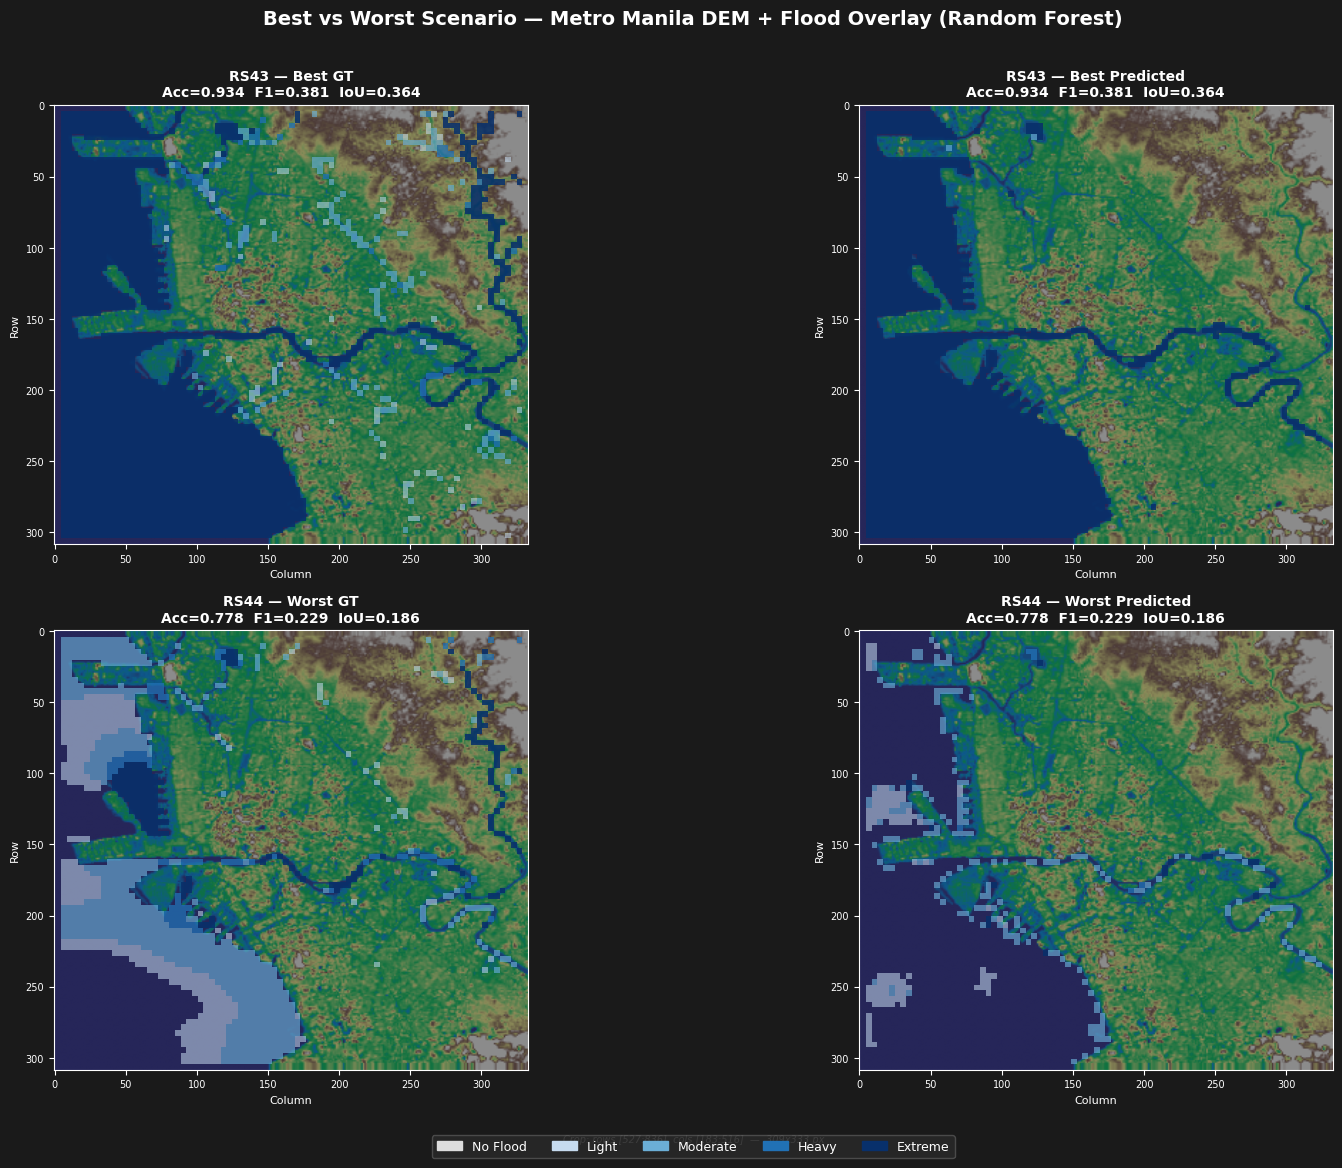

In [21]:
from rf_prediction import (
    reconstruct_ground_truth_maps_rf,
    generate_prediction_maps_rf,
    evaluate_predictions_rf,
    plot_best_worst_dem,
)

# Unique test scenario IDs
test_scenario_ids = list(dict.fromkeys(m['scenario_id'] for m in test_meta))

# Ground truth spatial maps
gt_maps = reconstruct_ground_truth_maps_rf(
    test_scenario_meta = test_meta,
    y_test             = y_test,
    test_scenario_ids  = test_scenario_ids,
)

# Predicted spatial maps
pred_results = generate_prediction_maps_rf(
    model              = best_model,
    X_test             = X_test,
    test_scenario_meta = test_meta,
    test_scenario_ids  = test_scenario_ids,
    cfg                = cfg,
)
pred_maps = pred_results['predictions']

# Per-scenario metrics
scenario_results = evaluate_predictions_rf(pred_maps, gt_maps, test_scenario_ids, cfg)

# Best vs worst DEM overlay
fig = plot_best_worst_dem(
    dem       = test_dem_preprocessed,
    results   = scenario_results,
    pred_maps = pred_maps,
    gt_maps   = gt_maps,
)